In [ ]:
from sdss_eval.paths import BINS_DIR, PROCESSED_DIR, RAW_DIR

In [1]:
%load_ext autoreload
%autoreload 2
from sdss_eval.sqlparser import schema
from sdss_eval.discretize import *
import json
from pandas_profiling import ProfileReport
from collections import Counter
%matplotlib inline
db = schema()

specobj_attrs = [
    "specobj.z",
    "specobj.ra",
    "specobj.dec"
    ]

photoobj_attrs = [
    "photoobj.ra",
    "photoobj.g",
    "photoobj.dec",
    "photoobj.u",
    ]

In [2]:
columns_w_between = Counter()
colstats = {}
for line in open(PROCESSED_DIR / 'where_log_th500.json'):
    row = json.loads(line)[0]
    for attr,val in row.items():
        for cond in val:
            if cond[0] == 'between' and not isinstance(cond[1],dict) and not isinstance(cond[2],dict) and not isinstance(cond[2],str):
                attr_name = db.get_column_name(int(attr))
                columns_w_between[attr_name]+=1

                if attr_name not in colstats:
                    colstats[attr_name] = {'min':cond[1], 'max' : cond[2] }
                else:
                    colstats[attr_name]['min'] = min(cond[1], colstats[attr_name]['min'])
                    colstats[attr_name]['max'] = max(cond[2], colstats[attr_name]['max'])
                    

columns_w_between.most_common(10)

[('specobj.z', 48919),
 ('photoobj.ra', 13147),
 ('photoobj.dec', 12559),
 ('specobj.ra', 11624),
 ('specobj.dec', 10939),
 ('photoobj.g', 9083),
 ('photoobj.u', 7968)]

In [4]:
columns_w_between.most_common(20)

[('specobj.z', 48919),
 ('photoobj.ra', 13147),
 ('photoobj.dec', 12559),
 ('specobj.ra', 11624),
 ('specobj.dec', 10939),
 ('photoobj.g', 9083),
 ('photoobj.u', 7968)]

In [3]:
# number of columns that have a between statement
len(columns_w_between)

369

In [6]:
def analyze_attributes(attributes , df):
    for attr in attributes:
        table, column = attr.split(".")
        profile = ProfileReport(
            df[[column]],
            title=attr,
            html={"style": {"full_width": True}},
            samples=None,
            correlations=None,
            missing_diagrams=None,
            duplicates=None,
            interactions=None,
        )
        profile.to_notebook_iframe()

        print("----- LOG ------")
        print('LOG:', colstats[attr])
        min, max = df[column].min() , df[column].max()
        # plot_hist_for_attr(attr,step=0.01)
        plot_hist_for_attr(attr,range=(min,max), step=0.01)

        plot_bin_width_for_attr(attr, range=None)
        plot_bin_width_for_attr(attr, range='auto')
        print('Average bin width (LOG):', avg_bin_width_for_attr(attr))

        print("----- Compute # of Bins ------")
        np_data = df[column].to_numpy()
        bin_width, bin_count = freedman_diaconis(np_data,plot=True)
        print(f'Freedman Diaconis width: {bin_width} , bins: {bin_count}')
        bin_width, bin_count = sturge_rule(np_data,plot=True)
        print(f'Sturge Rule width: {bin_width} , bins: {bin_count}')

## specobj

In [2]:
specobj = StaticBinning(specobj_attrs).data

,z,ra,dec
0,0.076223,1.495051,-10.684733
1,0.433399,1.065089,-10.113468
2,0.061479,0.196333,-10.802508
3,0.456655,0.387937,-10.510865
4,0.326078,0.702376,-10.347841
...,...,...,...
42814,-0.000864,358.907770,36.074346
42815,-0.000236,358.003340,38.579750
42816,-0.001213,358.661140,38.726208
42817,-0.000289,358.151660,39.873131


In [5]:
save_stats(specobj_attrs,specobj)

specobj.z: [('freedman_diaconis', {'bin_width': 0.034, 'bin_count': 207}), ('digits', 7), ('min', -0.00413608), ('max', 7.01124)] 
specobj.ra: [('freedman_diaconis', {'bin_width': 5.6541, 'bin_count': 64}), ('digits', 7), ('min', 0.033695866), ('max', 359.99852)] 
specobj.dec: [('freedman_diaconis', {'bin_width': 1.8141, 'bin_count': 57}), ('digits', 6), ('min', -18.655515), ('max', 84.195504)] 


In [9]:
EqualWidth(specobj_attrs).create_bins()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


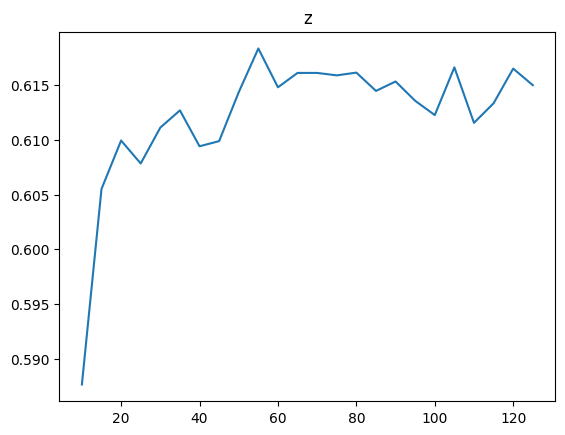

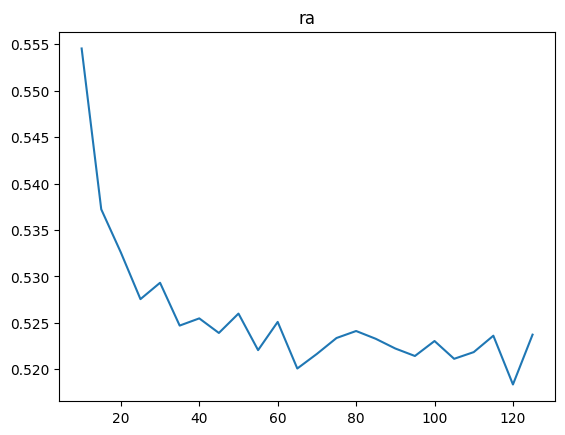

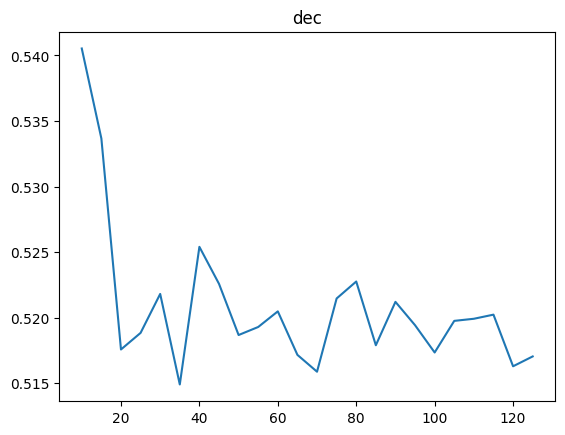

CPU times: user 13min 41s, sys: 2min 19s, total: 16min 1s
Wall time: 14min 46s


{'specobj.z': 55, 'specobj.ra': 10, 'specobj.dec': 10}

In [2]:
%%time
KMeansBinning(specobj_attrs).analyze_bins(kmax=128)

In [8]:
KMeansBinning(specobj_attrs).create_bins()

Render HTML: 100%|██████████| 1/1 [00:00<00:00, 70.40it/s]


----- LOG ------
LOG: {'min': -100, 'max': 10000}


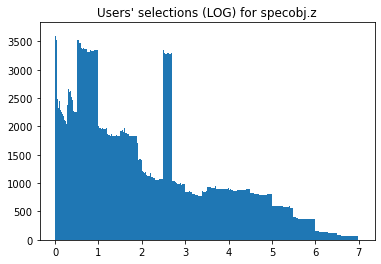

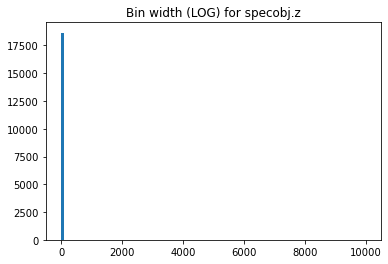

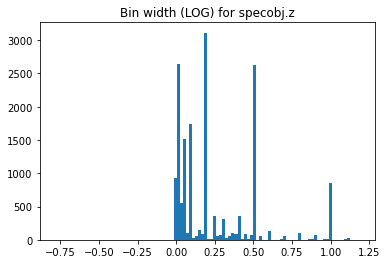

Average bin width (LOG): 0.25
----- Compute # of Bins ------


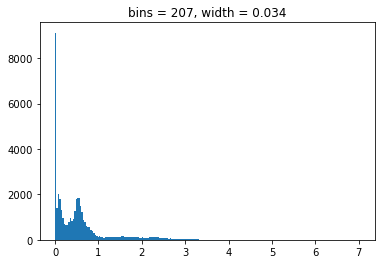

Freedman Diaconis width: 0.034 , bins: 207


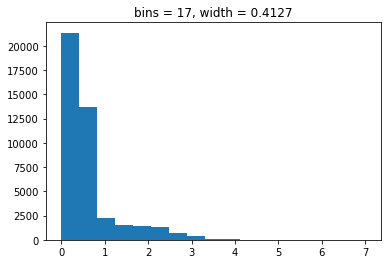

Summarize dataset:  29%|██▊       | 2/7 [00:00<00:00, 84.72it/s, Get dataframe statistics]

Sturge Rule width: 0.4127 , bins: 17


Render HTML: 100%|██████████| 1/1 [00:00<00:00, 68.11it/s]


----- LOG ------
LOG: {'min': -50, 'max': 1000000}


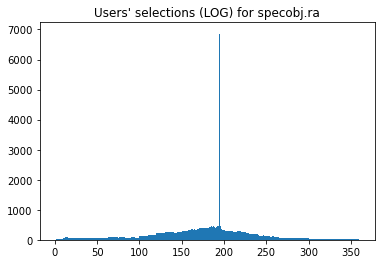

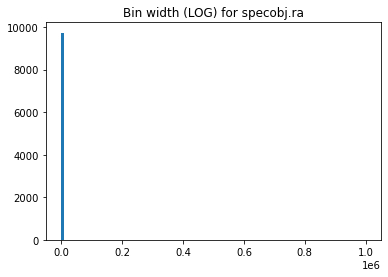

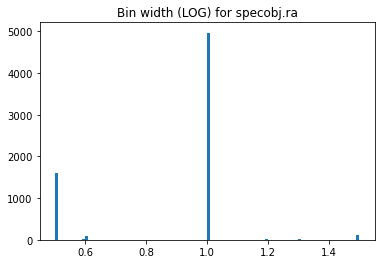

Average bin width (LOG): 1.0
----- Compute # of Bins ------


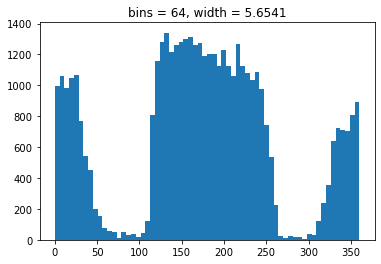

Freedman Diaconis width: 5.6541 , bins: 64


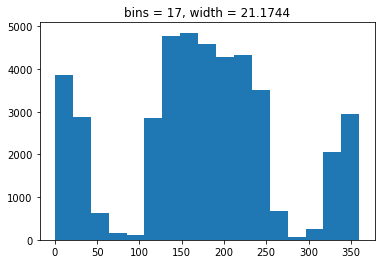

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Sturge Rule width: 21.1744 , bins: 17


Render HTML: 100%|██████████| 1/1 [00:00<00:00, 66.72it/s]


----- LOG ------
LOG: {'min': -180, 'max': 4248}


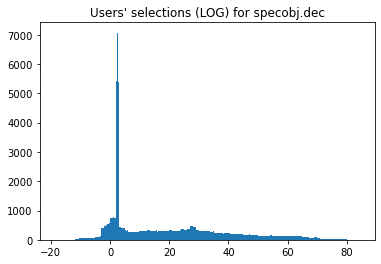

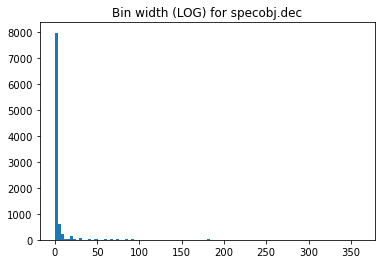

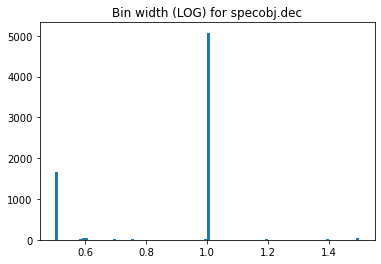

Average bin width (LOG): 1.0
----- Compute # of Bins ------


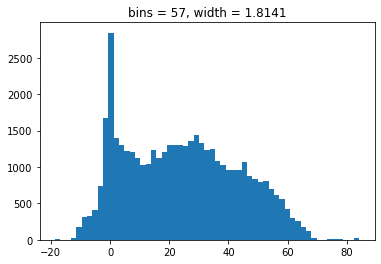

Freedman Diaconis width: 1.8141 , bins: 57


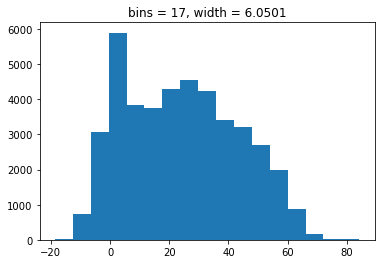

Sturge Rule width: 6.0501 , bins: 17
CPU times: user 5min 1s, sys: 2.98 s, total: 5min 4s
Wall time: 4min 59s


In [9]:
# %%time
analyze_attributes(specobj_attrs,specobj)

## photoobj

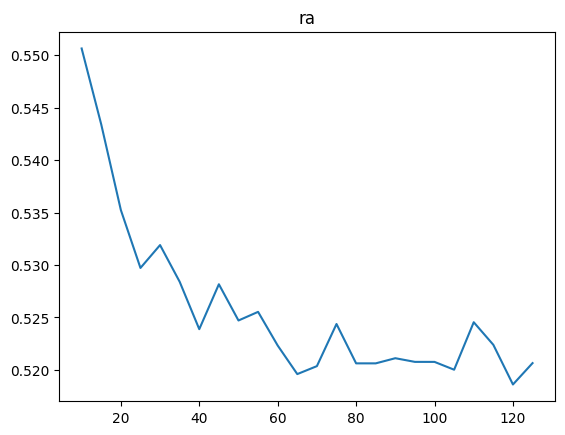

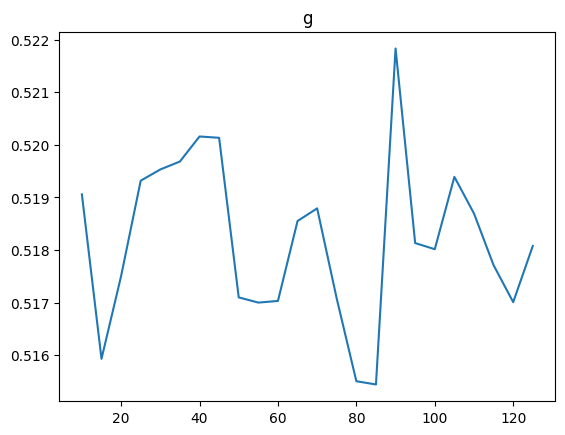

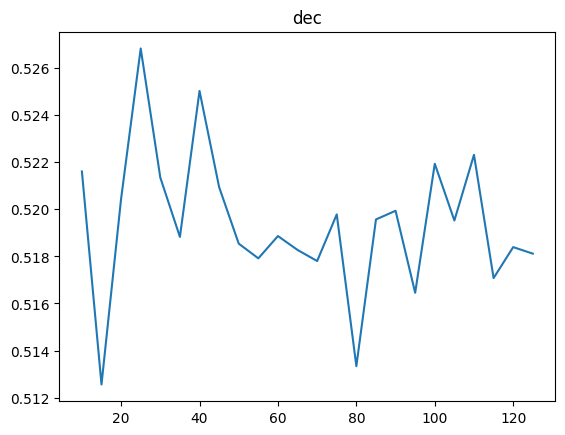

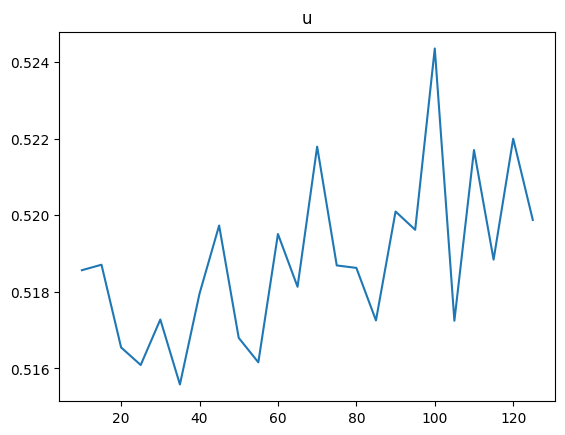

CPU times: user 15min 24s, sys: 2min 52s, total: 18min 17s
Wall time: 16min 35s


{'photoobj.ra': 10, 'photoobj.g': 90, 'photoobj.dec': 25, 'photoobj.u': 100}

In [7]:
%%time
KMeansBinning(photoobj_attrs).analyze_bins(kmax=128)

In [12]:
kmb = KMeansBinning(photoobj_attrs)
kmb.best_ks={'photoobj.ra': 10, 'photoobj.g': 90, 'photoobj.dec': 25, 'photoobj.u': 100}
kmb.create_bins()

In [10]:
photoobj = StaticBinning(photoobj_attrs).data

In [11]:
save_stats(photoobj_attrs,photoobj)

photoobj.ra: [('freedman_diaconis', {'bin_width': 5.7959, 'bin_count': 63}), ('digits', 13), ('min', 0.0007402157647788), ('max', 359.9952132335)] 
photoobj.g: [('freedman_diaconis', {'bin_width': 0.187, 'bin_count': 96}), ('digits', 4), ('min', 12.1012), ('max', 29.9941)] 
photoobj.dec: [('freedman_diaconis', {'bin_width': 1.829, 'bin_count': 57}), ('digits', 15), ('min', -18.7378627147366), ('max', 84.4868534664317)] 
photoobj.u: [('freedman_diaconis', {'bin_width': 0.1952, 'bin_count': 86}), ('digits', 4), ('min', 13.5197), ('max', 30.2539)] 


In [13]:
EqualWidth(photoobj_attrs).create_bins()

Render HTML: 100%|██████████| 1/1 [00:00<00:00, 55.11it/s]


----- LOG ------
LOG: {'min': -180.0, 'max': 2279}


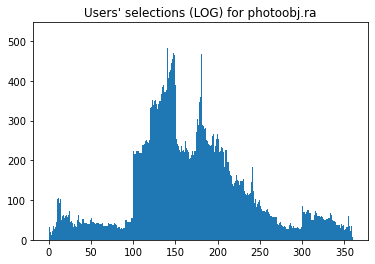

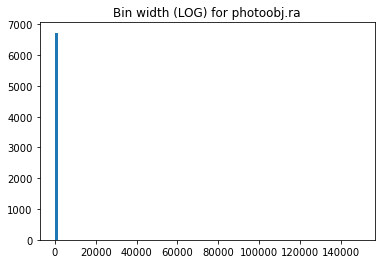

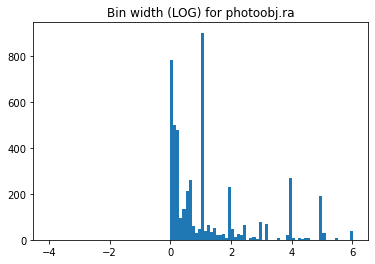

Average bin width (LOG): 1.23
----- Compute # of Bins ------


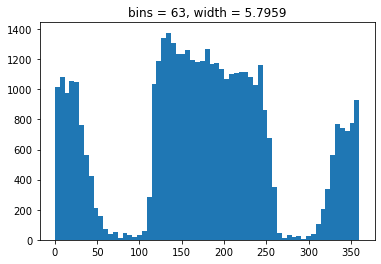

Freedman Diaconis width: 5.7959 , bins: 63


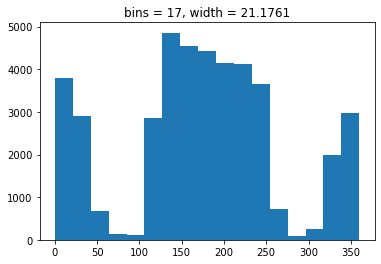

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Sturge Rule width: 21.1761 , bins: 17


Render HTML: 100%|██████████| 1/1 [00:00<00:00, 70.12it/s]


----- LOG ------
LOG: {'min': -9999, 'max': 10000}


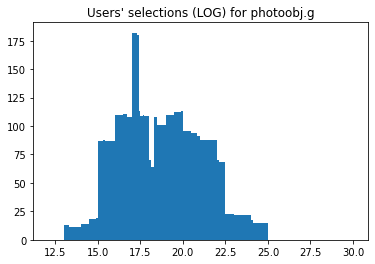

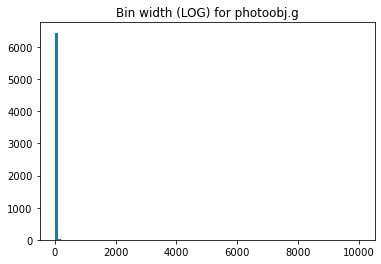

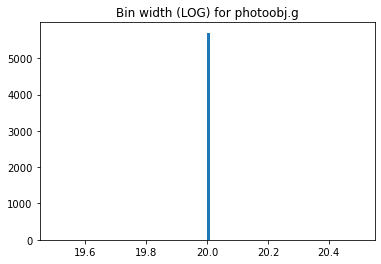

Average bin width (LOG): 20.0
----- Compute # of Bins ------


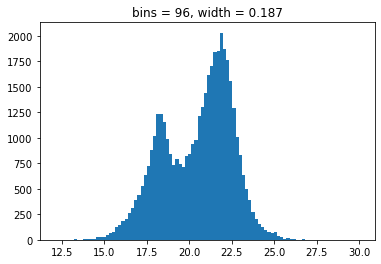

Freedman Diaconis width: 0.187 , bins: 96


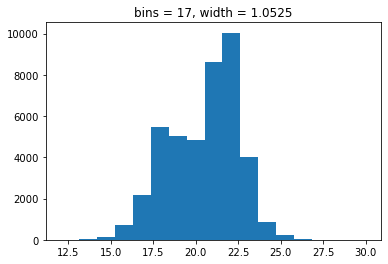

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Sturge Rule width: 1.0525 , bins: 17


Render HTML: 100%|██████████| 1/1 [00:00<00:00, 66.56it/s]


----- LOG ------
LOG: {'min': -49972044, 'max': 11382.4}


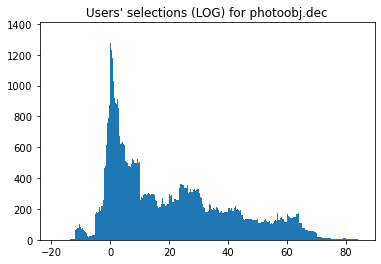

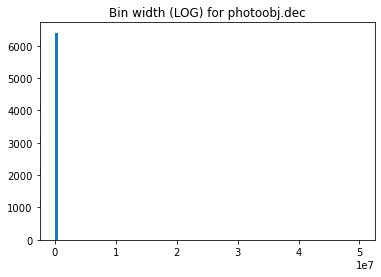

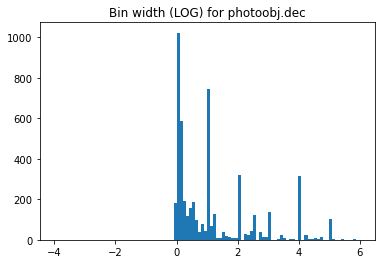

Average bin width (LOG): 1.15
----- Compute # of Bins ------


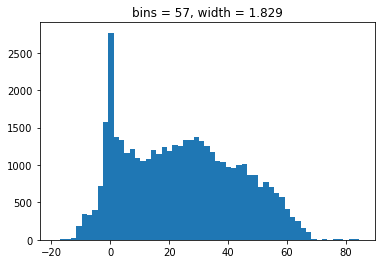

Freedman Diaconis width: 1.829 , bins: 57


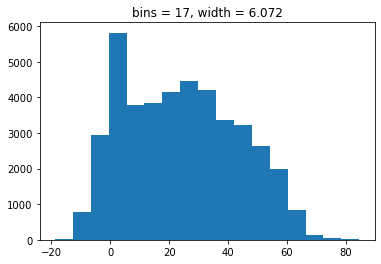

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Sturge Rule width: 6.072 , bins: 17


Render HTML: 100%|██████████| 1/1 [00:00<00:00, 68.50it/s]


----- LOG ------
LOG: {'min': -9999, 'max': 999.99}


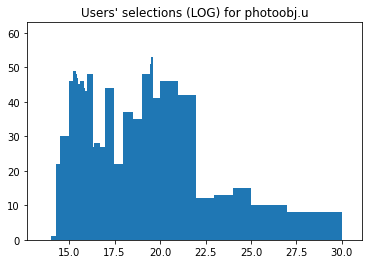

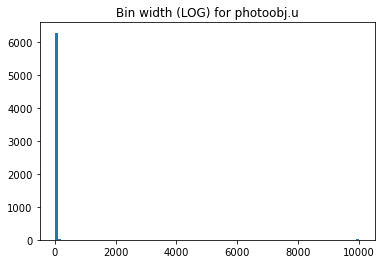

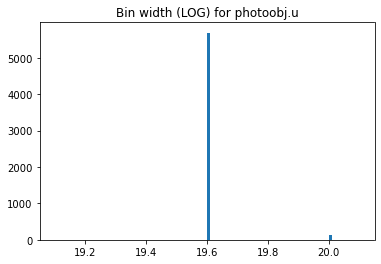

Average bin width (LOG): 19.6
----- Compute # of Bins ------


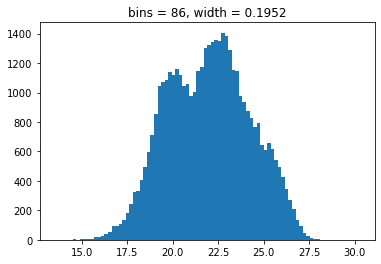

Freedman Diaconis width: 0.1952 , bins: 86


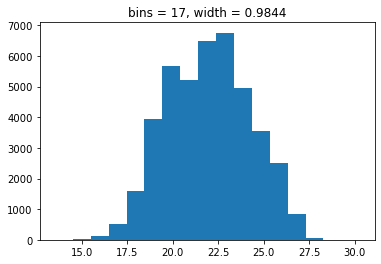

Sturge Rule width: 0.9844 , bins: 17
CPU times: user 6min 29s, sys: 3.71 s, total: 6min 32s
Wall time: 6min 26s


In [18]:
%%time
analyze_attributes(attributes, df)

## Showcase photoobj.dec

In [1]:
from sdss_eval.discretize import *
import pandas as pd

In [3]:
df1 = pd.read_csv(BINS_DIR / 'specobj.csv')

/Users/antonismand/miniforge3/envs/thesis/lib/python3.9/site-packages/tikzplotlib/_cleanfigure.py:200: UserWarning: Cleaning Bar Container (bar plot) is not supported yet.
  warnings.warn("Cleaning Bar Container (bar plot) is not supported yet.")


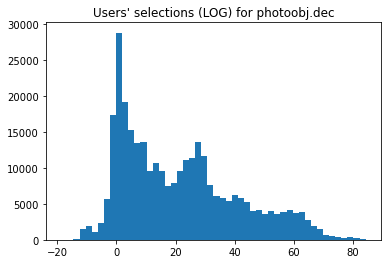

In [4]:
min, max = df1['dec'].min() , df1['dec'].max()
plot_hist_for_attr("photoobj.dec",range=(min,max), step=0.1,bins = 50)

/Users/antonismand/miniforge3/envs/thesis/lib/python3.9/site-packages/tikzplotlib/_cleanfigure.py:200: UserWarning: Cleaning Bar Container (bar plot) is not supported yet.
  warnings.warn("Cleaning Bar Container (bar plot) is not supported yet.")


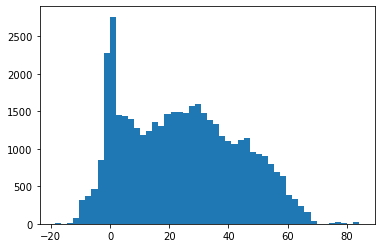

In [20]:
_, ax = plt.subplots()
ax.hist(df1['dec'],bins=50)

tikzplotlib.clean_figure()
tikzplotlib.save(
    f"plots/db-photoobj-dec.tex",
    extra_axis_parameters=["scaled x ticks=false", "scaled y ticks=false"],
    axis_height="\\figH",
    axis_width="\\figW",
)